## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

## Load Dataset

In [3]:
# Daily customer traffic
customers = pd.read_csv('OutletDailyCustomers.csv', index_col=0)

# Outlet level datasets
marketing = pd.read_csv('OutletMarketing.csv', index_col=0)
overheads = pd.read_csv('OutletOverheads.csv', index_col=0)
size = pd.read_csv('OutletSize.csv', index_col=0)
staff = pd.read_csv('OutletStaff.csv', index_col=0)

## Merge Outlet-Level Variables

In [4]:
# Merge datasets
retail_df = marketing.merge(overheads, on='Id')
retail_df = retail_df.merge(size, on='Id')
retail_df = retail_df.merge(staff, on='Id')

# Rename columns
retail_df.rename(columns={
    'Marketing (£)': 'Marketing',
    'Overheads (£)': 'Overheads',
    'Size (msq)': 'Size'
}, inplace=True)

In [5]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, CGV to NLT
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Marketing  45 non-null     int64
 1   Overheads  45 non-null     int64
 2   Size       45 non-null     int64
 3   Staff      45 non-null     int64
dtypes: int64(4)
memory usage: 1.8+ KB


## Create Customer Traffic Variable

In [6]:
# Calculate total customers per store
retail_df['Customers'] = customers.sum().values

## Exploratory Data Analysis (EDA)

### Customer Traffic Trends

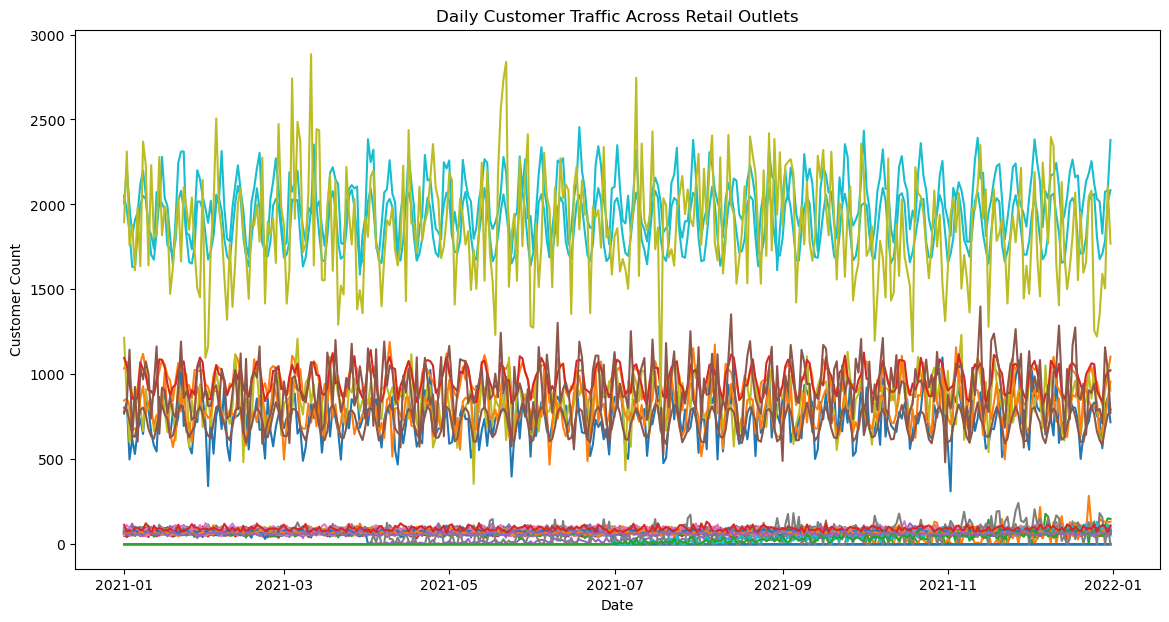

In [7]:
customers.index = pd.to_datetime(customers.index)

plt.figure(figsize=(14,7))
plt.plot(customers)
plt.title('Daily Customer Traffic Across Retail Outlets')
plt.xlabel('Date')
plt.ylabel('Customer Count')
plt.show()

### Store Category Classification

In [8]:
large = []
medium = []
small = []

for col in customers.columns:
    total = customers[col].sum()

    if total > 300000:
        large.append(col)
    elif total > 100000:
        medium.append(col)
    else:
        small.append(col)

### Bar Chart Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

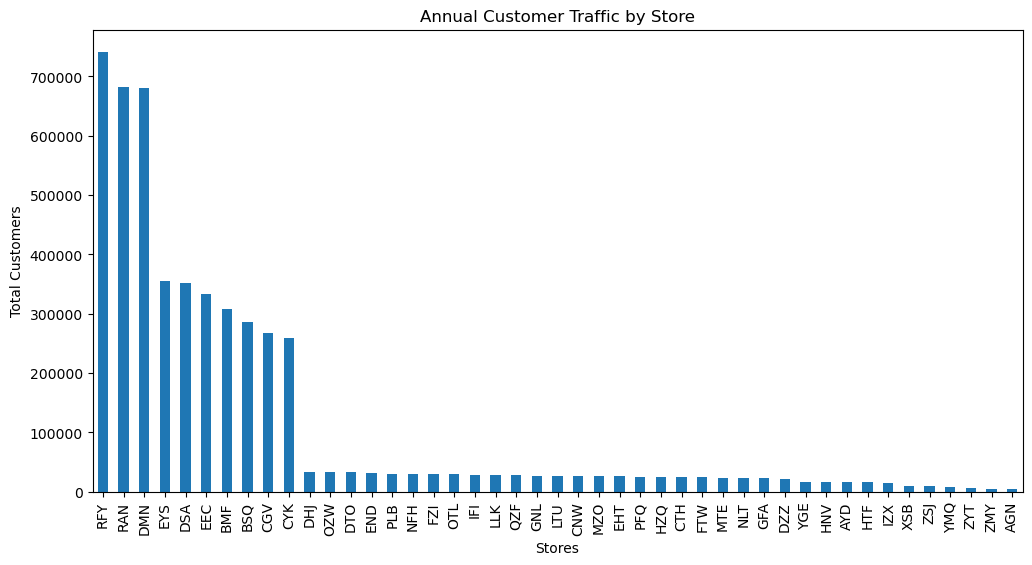

In [9]:
store_totals = customers.sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
store_totals.plot(kind='bar')
plt.title('Annual Customer Traffic by Store')
plt.xlabel('Stores')
plt.ylabel('Total Customers')
plt.show

### Rolling Average Analysis

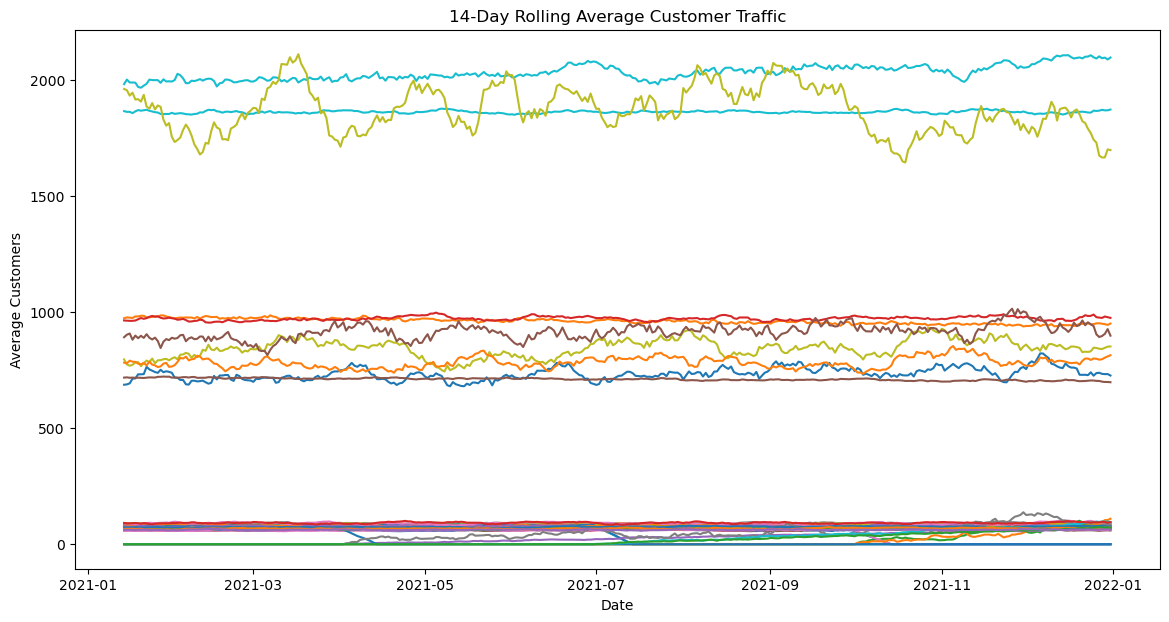

In [10]:
rolling_avg = customers.rolling(window=14).mean()

plt.figure(figsize=(14,7))
plt.plot(rolling_avg)
plt.title('14-Day Rolling Average Customer Traffic')
plt.xlabel('Date')
plt.ylabel('Average Customers')
plt.show()

### Bubble Plot Analysis

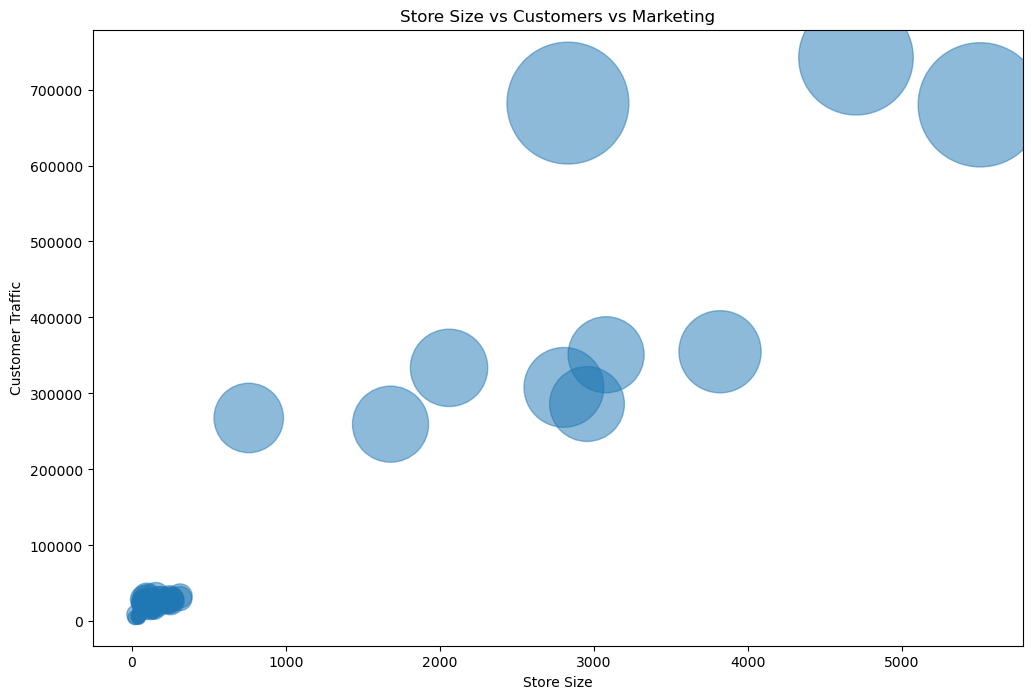

In [11]:
retail_df['BubbleSize'] = retail_df['Marketing'] * 0.1

plt.figure(figsize=(12,8))
plt.scatter(
    retail_df['Size'],
    retail_df['Customers'],
    s=retail_df['BubbleSize'],
    alpha=0.5
)

plt.xlabel('Store Size')
plt.ylabel('Customer Traffic')
plt.title('Store Size vs Customers vs Marketing')
plt.show()

## Feature Engineering

### Create Store Categories

In [12]:
store_category = []

for value in retail_df['Customers']:
    if value > 300000:
        store_category.append('Large')
    elif value > 100000:
        store_category.append('Medium')
    else:
        store_category.append('Small')

retail_df['Category'] = store_category

### Encode Categories

In [13]:
encoder = LabelEncoder()
retail_df['Category_Encoded'] = encoder.fit_transform(retail_df['Category'])

## Correlation Analysis

### Correlation Heatmap

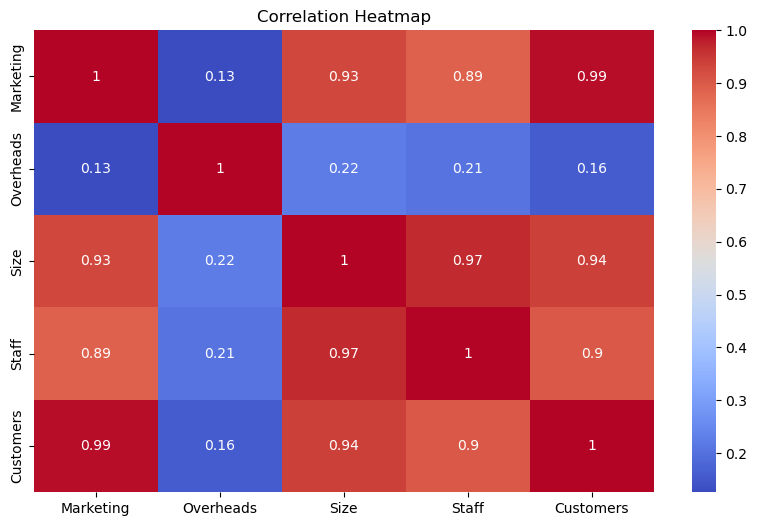

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(
    retail_df[['Marketing','Overheads','Size','Staff','Customers']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

## Predictive Modelling

### Define Features and Target

In [15]:
X = retail_df[['Marketing','Overheads','Size','Staff']]
y = retail_df['Customers']

### Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Linear Regression Model

In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

### Evaluate Linear Regression

In [18]:
print('Linear Regression Results')
print('R2 Score:', r2_score(y_test, lr_predictions))
print('MAE:', mean_absolute_error(y_test, lr_predictions))
print('RMSE:', np.sqrt(mean_squared_error(y_test, lr_predictions)))

Linear Regression Results
R2 Score: 0.9853253941306848
MAE: 12113.78762213465
RMSE: 15910.367160124551


### K-Means Clustering

In [21]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select features for clustering
cluster_features = retail_df[['Marketing', 'Size', 'Staff', 'Customers']]

# Scale features
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

# Apply Agglomerative Clustering
agg_cluster = AgglomerativeClustering(n_clusters=3)

retail_df['Cluster'] = agg_cluster.fit_predict(cluster_scaled)

# View clustered stores
retail_df[['Marketing', 'Size', 'Staff', 'Customers', 'Cluster']]

,Marketing,Size,Staff,Customers,Cluster
Id,,,,,
CGV,25000,760,6,267734,0
DSA,30000,3081,38,350937,0
ZMY,1000,45,1,5139,1
MZO,3000,231,3,26992,1
OTL,4000,82,1,28831,1
GFA,3000,167,2,22103,1
PFQ,3000,80,1,25005,1
NFH,3000,313,4,30017,1
BMF,33000,2807,17,308018,0


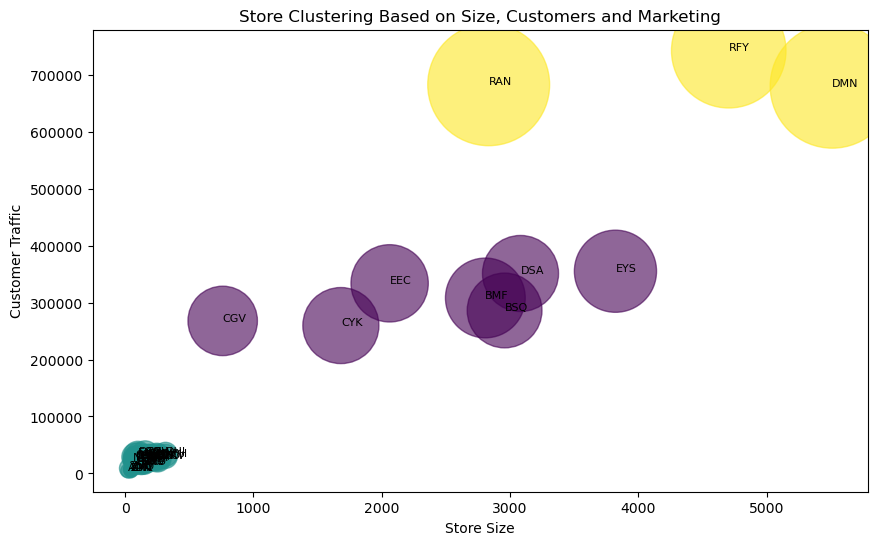

In [22]:
plt.figure(figsize=(10,6))

plt.scatter(
    retail_df['Size'],
    retail_df['Customers'],
    c=retail_df['Cluster'],
    s=retail_df['Marketing'] * 0.1,
    alpha=0.6
)

plt.title('Store Clustering Based on Size, Customers and Marketing')
plt.xlabel('Store Size')
plt.ylabel('Customer Traffic')

for store in retail_df.index:
    plt.annotate(
        store,
        (retail_df.loc[store, 'Size'], retail_df.loc[store, 'Customers']),
        fontsize=8
    )

plt.show()

### Evaluate K-Means

In [23]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(cluster_scaled, retail_df['Cluster'])

print("Silhouette Score:", sil_score)

Silhouette Score: 0.8347390781636334
